
# Plant Leaf Disease Classification using Deep Learning

**Module Name:** M507 Methods of Prediction                            
**Student Name:** Rakesh Goud Gajjela                                                
**Student ID (GH No.):** GH1052130

## 1. Problem Statement

### Business Context

Crop disease is a major source of agricultural loss worldwide, while smallholder farmers may have limited access to agricultural experts for timely disease diagnosis (Singh et al., 2020). An image-based tool that allows farmers to photograph a leaf and receive an automated diagnosis could support earlier detection, reduce avoidable crop losses and improve treatment decisions.

### Why This Matters to the Company

For an agritech company, an image-based disease classifier could be integrated into a mobile application, offered as a B2B API to agricultural cooperatives, or connected to farm-monitoring systems. Faster and more accurate disease identification could support targeted treatment and strengthen the company's agricultural technology services.

### Data Collection

This project uses the publicly available **PlantDoc** dataset rather than collecting new data. PlantDoc contains real-world plant images collected from online sources and manually verified (Singh et al., 2020). Its varied backgrounds, lighting and image conditions make it relevant to a real-world classification scenario. In production, the company could supplement the dataset with labelled field images collected with support from farmers and agronomists.

**Dataset Source:** PlantDoc (Singh et al., 2020) — https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset

### Machine Learning Formulation

The problem is formulated as a **multi-class image classification task**. Given an RGB image of a plant leaf, the model predicts its corresponding leaf or disease category. A convolutional neural network (CNN), implemented using Keras/TensorFlow, is trained to learn the relationship between image features and the target categories.


## 2. Dataset Description

The PlantDoc dataset contains labelled images of plant leaves representing multiple plant species and disease categories. The dataset is divided into separate training and test folders, with each class represented by a subfolder.

The dataset is suitable for this project because it contains real-world images with variation in image size, lighting and background. These characteristics make the classification task more representative of practical agricultural applications.

**Dataset:** PlantDoc  
**Source:** Kaggle  
**URL:** https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset

## 2. Dataset Loading and Initial Setup

The PlantDoc dataset is loaded and prepared for image-based classification. The required libraries are imported, and the dataset directory is defined for subsequent exploration and preprocessing.

In [1]:
!pip -q install kaggle

In [2]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [3]:
!mkdir -p /content/plantdoc
!kaggle datasets download nirmalsankalana/plantdoc-dataset \
    -p /content/plantdoc --unzip

Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset
License(s): CC0-1.0
100% 896M/896M [00:51<00:00, 18.1MB/s]



In [4]:
base_path = "/content/plantdoc"

print("Files/folders in PlantDoc:")
for item in os.listdir(base_path):
    print(item)

Files/folders in PlantDoc:
file_renamer.py
folder_renamer.py
train
test


## 3. Dataset Exploration and Data Quality

The dataset contains images organised into class-specific folders. Class counts, image validity and image dimensions are examined to identify imbalance and quality issues before modelling.

In [7]:
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

print("Training classes:", len(os.listdir(train_path)))
print("Test classes:", len(os.listdir(test_path)))

print("\nTraining classes:")
print(sorted(os.listdir(train_path)))

Training classes: 28
Test classes: 27

Training classes:
['Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Bell_pepper_leaf', 'Bell_pepper_leaf_spot', 'Blueberry_leaf', 'Cherry_leaf', 'Corn_Gray_leaf_spot', 'Corn_leaf_blight', 'Corn_rust_leaf', 'Peach_leaf', 'Potato_leaf_early_blight', 'Potato_leaf_late_blight', 'Raspberry_leaf', 'Soyabean_leaf', 'Squash_Powdery_mildew_leaf', 'Strawberry_leaf', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_spot', 'Tomato_leaf', 'Tomato_leaf_bacterial_spot', 'Tomato_leaf_late_blight', 'Tomato_leaf_mosaic_virus', 'Tomato_leaf_yellow_virus', 'Tomato_mold_leaf', 'Tomato_two_spotted_spider_mites_leaf', 'grape_leaf', 'grape_leaf_black_rot']


### Dataset Structure

The training set contains 28 classes, whereas the test set contains 27. This difference requires investigation before preprocessing and modelling to ensure that the class structure is handled consistently.

In [8]:
train_classes = set(os.listdir(train_path))
test_classes = set(os.listdir(test_path))

print("Class present only in training:")
print(train_classes - test_classes)

print("\nClass present only in test:")
print(test_classes - train_classes)

Class present only in training:
{'Tomato_two_spotted_spider_mites_leaf'}

Class present only in test:
set()


The test set does not contain the `Tomato_two_spotted_spider_mites_leaf` class. Therefore, this class cannot contribute to test-set evaluation and requires consideration when defining the modelling classes.

In [9]:
from collections import Counter

train_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in train_classes
}

test_counts = {
    cls: len(os.listdir(os.path.join(test_path, cls)))
    for cls in test_classes
}

print("Total training images:", sum(train_counts.values()))
print("Total test images:", sum(test_counts.values()))

print("\nTraining images per class:")
for cls, count in sorted(train_counts.items()):
    print(f"{cls}: {count}")

Total training images: 2670
Total test images: 252

Training images per class:
Apple_Scab_Leaf: 83
Apple_leaf: 79
Apple_rust_leaf: 96
Bell_pepper_leaf: 34
Bell_pepper_leaf_spot: 74
Blueberry_leaf: 106
Cherry_leaf: 47
Corn_Gray_leaf_spot: 63
Corn_leaf_blight: 182
Corn_rust_leaf: 107
Peach_leaf: 103
Potato_leaf_early_blight: 157
Potato_leaf_late_blight: 200
Raspberry_leaf: 112
Soyabean_leaf: 57
Squash_Powdery_mildew_leaf: 124
Strawberry_leaf: 88
Tomato_Early_blight_leaf: 79
Tomato_Septoria_leaf_spot: 145
Tomato_leaf: 44
Tomato_leaf_bacterial_spot: 101
Tomato_leaf_late_blight: 101
Tomato_leaf_mosaic_virus: 44
Tomato_leaf_yellow_virus: 223
Tomato_mold_leaf: 85
Tomato_two_spotted_spider_mites_leaf: 2
grape_leaf: 63
grape_leaf_black_rot: 71


### Class Distribution

The training data are strongly imbalanced, with class sizes ranging from 2 to 223 images. The `Tomato_two_spotted_spider_mites_leaf` class contains only two training images and is absent from the test set, making reliable learning and evaluation for this class impractical.

In [10]:
import pandas as pd

class_summary = pd.DataFrame({
    "Class": list(train_counts.keys()),
    "Training Images": list(train_counts.values())
}).sort_values("Training Images")

class_summary["Percentage"] = (
    class_summary["Training Images"] / class_summary["Training Images"].sum() * 100
).round(2)

print(class_summary.to_string(index=False))
print("\nSmallest class:", class_summary.iloc[0]["Training Images"])
print("Largest class:", class_summary.iloc[-1]["Training Images"])
print("Imbalance ratio:", round(
    class_summary.iloc[-1]["Training Images"] /
    class_summary.iloc[0]["Training Images"], 1
))

                               Class  Training Images  Percentage
Tomato_two_spotted_spider_mites_leaf                2        0.07
                    Bell_pepper_leaf               34        1.27
            Tomato_leaf_mosaic_virus               44        1.65
                         Tomato_leaf               44        1.65
                         Cherry_leaf               47        1.76
                       Soyabean_leaf               57        2.13
                 Corn_Gray_leaf_spot               63        2.36
                          grape_leaf               63        2.36
                grape_leaf_black_rot               71        2.66
               Bell_pepper_leaf_spot               74        2.77
                          Apple_leaf               79        2.96
            Tomato_Early_blight_leaf               79        2.96
                     Apple_Scab_Leaf               83        3.11
                    Tomato_mold_leaf               85        3.18
          

The class distribution is highly imbalanced: the largest class contains 223 images compared with only 2 in the smallest class, giving an imbalance ratio of 111.5:1. This imbalance may cause the model to favour better-represented classes, so class balancing strategies will be considered during model development.

In [11]:
from PIL import Image

sizes = []

for cls in train_classes:
    class_path = os.path.join(train_path, cls)
    for file in os.listdir(class_path):
        try:
            with Image.open(os.path.join(class_path, file)) as img:
                sizes.append(img.size)
        except:
            pass

print("Total valid training images checked:", len(sizes))
print("Unique image dimensions:", len(set(sizes)))
print("Most common dimensions:", Counter(sizes).most_common(10))

Total valid training images checked: 2670
Unique image dimensions: 1619
Most common dimensions: [((300, 300), 195), ((1600, 1200), 52), ((800, 600), 40), ((1024, 768), 32), ((1200, 1600), 23), ((640, 480), 19), ((400, 300), 17), ((1200, 900), 17), ((500, 375), 16), ((900, 675), 15)]


In [12]:
valid_images = 0
invalid_images = 0

for cls in train_classes:
    class_path = os.path.join(train_path, cls)

    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)
        try:
            with Image.open(file_path) as img:
                img.verify()
            valid_images += 1
        except:
            invalid_images += 1

print("Valid images:", valid_images)
print("Invalid/corrupted images:", invalid_images)

Valid images: 2670
Invalid/corrupted images: 0


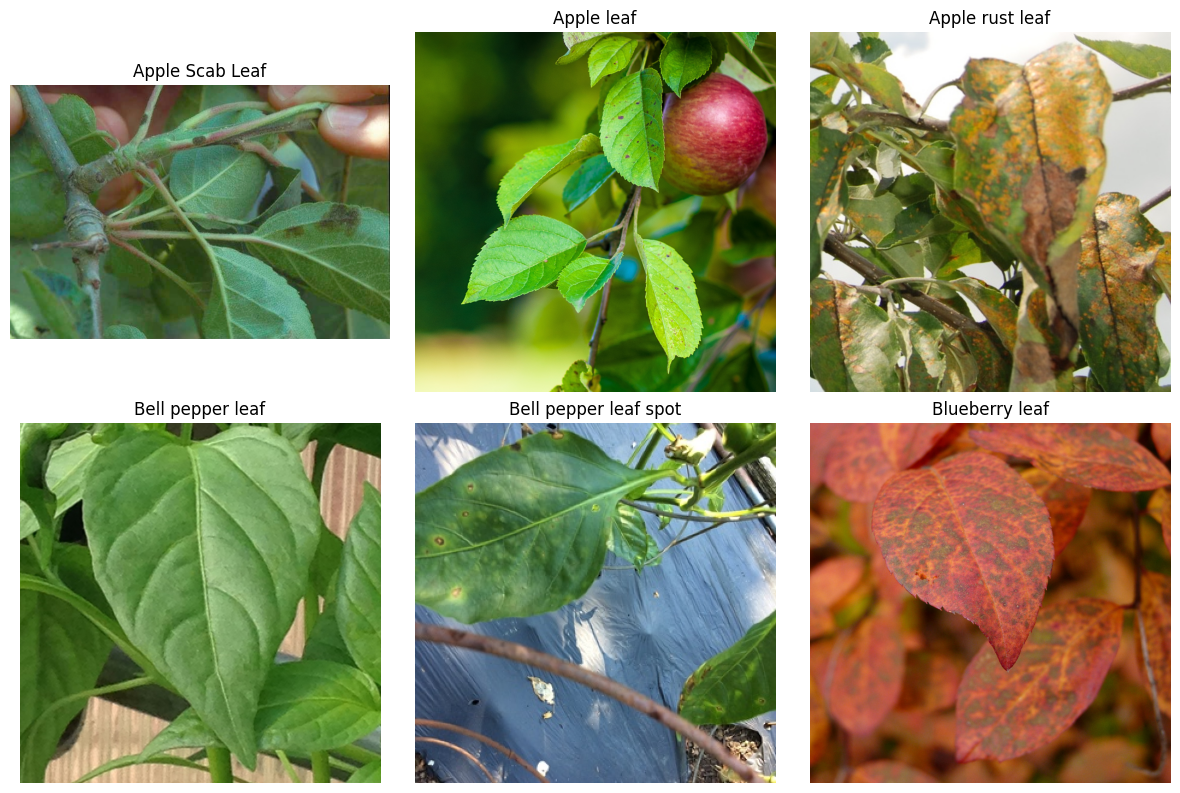

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

sample_classes = sorted(list(train_classes))[:6]

plt.figure(figsize=(12, 8))

for i, cls in enumerate(sample_classes):
    class_path = os.path.join(train_path, cls)
    image_file = os.listdir(class_path)[0]

    img = Image.open(os.path.join(class_path, image_file))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls.replace("_", " "))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
image_modes = Counter()

for cls in train_classes:
    class_path = os.path.join(train_path, cls)

    for file in os.listdir(class_path):
        try:
            with Image.open(os.path.join(class_path, file)) as img:
                image_modes[img.mode] += 1
        except:
            pass

print("Image colour modes:")
for mode, count in image_modes.items():
    print(f"{mode}: {count}")

Image colour modes:
RGB: 2659
CMYK: 5
RGBA: 5
L: 1


In [15]:
image_formats = Counter()

for cls in train_classes:
    class_path = os.path.join(train_path, cls)

    for file in os.listdir(class_path):
        try:
            with Image.open(os.path.join(class_path, file)) as img:
                image_formats[img.format] += 1
        except:
            pass

print("Image file formats:")
for fmt, count in image_formats.items():
    print(f"{fmt}: {count}")

Image file formats:
JPEG: 2664
PNG: 5
MPO: 1


In [16]:
excluded_class = "Tomato_two_spotted_spider_mites_leaf"

model_classes = sorted(train_classes - {excluded_class})

print("Number of modelling classes:", len(model_classes))
print("Excluded class:", excluded_class)
print("Images retained for modelling:",
      sum(train_counts[c] for c in model_classes))

Number of modelling classes: 27
Excluded class: Tomato_two_spotted_spider_mites_leaf
Images retained for modelling: 2668


### Modelling Classes

The class with only two training images was excluded because it is absent from the test set. The final modelling dataset therefore contains 27 classes and 2,668 training images, ensuring that all model classes can be assessed using the provided test data.

In [17]:
from sklearn.model_selection import train_test_split

image_paths = []
labels = []

for cls in model_classes:
    class_path = os.path.join(train_path, cls)

    for file in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, file))
        labels.append(cls)

data_df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

train_df, val_df = train_test_split(
    data_df,
    test_size=0.20,
    stratify=data_df["label"],
    random_state=42
)

print("Total modelling images:", len(data_df))
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Training classes:", train_df["label"].nunique())
print("Validation classes:", val_df["label"].nunique())

Total modelling images: 2668
Training images: 2134
Validation images: 534
Training classes: 27
Validation classes: 27


In [19]:
split_summary = pd.DataFrame({
    "Training": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts()
}).fillna(0).astype(int)

split_summary["Validation %"] = (
    split_summary["Validation"] /
    (split_summary["Training"] + split_summary["Validation"]) * 100
).round(1)

print(split_summary.sort_index().to_string())

                            Training  Validation  Validation %
label                                                         
Apple_Scab_Leaf                   66          17          20.5
Apple_leaf                        63          16          20.3
Apple_rust_leaf                   77          19          19.8
Bell_pepper_leaf                  27           7          20.6
Bell_pepper_leaf_spot             59          15          20.3
Blueberry_leaf                    85          21          19.8
Cherry_leaf                       38           9          19.1
Corn_Gray_leaf_spot               50          13          20.6
Corn_leaf_blight                 146          36          19.8
Corn_rust_leaf                    86          21          19.6
Peach_leaf                        82          21          20.4
Potato_leaf_early_blight         126          31          19.7
Potato_leaf_late_blight          160          40          20.0
Raspberry_leaf                    90          22       

The stratified split preserves similar class proportions in the training and validation sets, with approximately 20% of each class assigned to validation.

## 4. Data Preprocessing

In [20]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Target image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Target image size: (224, 224)
Batch size: 32


In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=model_classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=model_classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 2668 files belonging to 27 classes.
Using 2135 files for training.
Found 2668 files belonging to 27 classes.
Using 533 files for validation.
Training batches: 67
Validation batches: 17


In [50]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

class_to_index = {cls: i for i, cls in enumerate(model_classes)}

train_paths = train_df["filepath"].values
train_labels = train_df["label"].map(class_to_index).values

val_paths = val_df["filepath"].values
val_labels = val_df["label"].map(class_to_index).values

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(len(train_df), seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Training images: 2134
Validation images: 534
Training batches: 67
Validation batches: 17


In [23]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


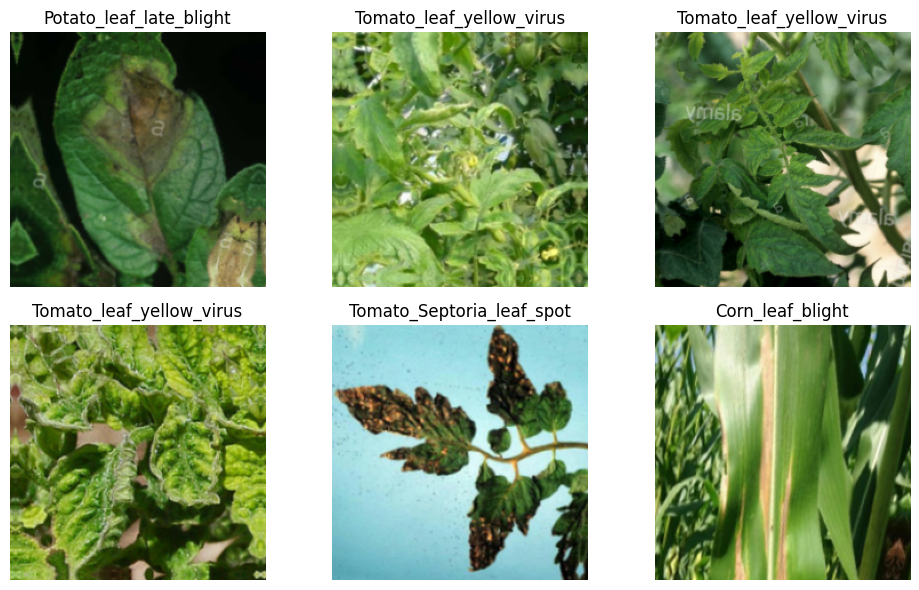

In [24]:
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)

    plt.figure(figsize=(10, 6))

    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(augmented_images[i].numpy())
        plt.title(model_classes[labels[i].numpy()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [25]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel value range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel value range: 0.0 to 1.0


In [51]:
def preprocess_test_image(image, label):
    image = tf.cast(image, tf.float32)
    return image, label

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="int",
    class_names=model_classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = test_ds.map(
    preprocess_test_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Test images:", 252)
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 252 files belonging to 27 classes.
Test images: 252
Test batches: 8


The unseen test set contains 252 images across the same 27 modelling classes. Test images are resized and normalized but are not augmented, ensuring that final performance is measured on the original unseen data.

## 5. Model Development

### 5.1 Experimental Model Configurations

Ten neural network configurations were previously trained using the same PlantDoc modelling dataset. The experiments varied the network architecture, data augmentation, class weighting, dropout, batch normalization, transfer learning and fine-tuning strategies. Validation accuracy was used to compare the configurations before selecting the final model for unseen test-set evaluation.

| Experiment | Model Configuration | Best Validation Accuracy | Lowest Validation Loss |
|---|---|---:|---:|
| 1 | Baseline CNN | 21.50% | 3.5713 |
| 2 | CNN + Data Augmentation | 26.00% | 2.7319 |
| 3 | CNN + Class Weights | 14.75% | 3.1026 |
| 4 | CNN + Data Augmentation + Class Weights | 18.75% | 2.8512 |
| 5 | CNN + Data Augmentation + Dropout | 26.25% | 2.6003 |
| 6 | CNN + Data Augmentation + Dropout + Batch Normalization | 8.50% | 3.2064 |
| 7 | MobileNetV2 + Data Augmentation | **57.25%** | **1.4280** |
| 8 | MobileNetV2 + Fine-tuning | 56.25% | 1.4444 |
| 9 | MobileNetV2 + Data Augmentation + Class Weights | 55.00% | 1.5064 |
| 10 | MobileNetV2 + Data Augmentation + Learning Rate 0.0001 | 45.00% | 1.9164 |

### 5.2 Model Selection

The experimental comparison shows that MobileNetV2 with data augmentation achieved the highest validation accuracy of 57.25% and the lowest validation loss of 1.4280 among the tested configurations. Therefore, this configuration was selected as the final model for evaluation on the unseen test set.

### 5.3 Final Model Architecture

The selected model uses MobileNetV2 with ImageNet pretrained weights. The pretrained convolutional base is frozen so that the model can use previously learned visual features while a new classification layer learns the 27 PlantDoc classes. Data augmentation is applied during training to improve generalisation.

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

num_classes = len(model_classes)

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

final_model = models.Model(inputs, outputs)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │        34,587 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,292,571 (8.75 MB)

 Trainable params: 34,587 (135.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 5.4 Final Model Training

The selected MobileNetV2 model is trained for up to 15 epochs using the training and validation datasets. Early stopping monitors validation loss and restores the best-performing model weights to reduce overfitting.

In [33]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

final_model = models.Model(inputs, outputs)

final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Final model rebuilt successfully.")

Final model rebuilt successfully.


In [49]:
def get_early_stopping():
    return tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )

In [34]:
history_final = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[get_early_stopping()],
    verbose=1
)

Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.2198 - loss: 2.8378 - val_accuracy: 0.3970 - val_loss: 2.0513
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 37s 214ms/step - accuracy: 0.4157 - loss: 1.9361 - val_accuracy: 0.4551 - val_loss: 1.8036
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 37s 154ms/step - accuracy: 0.5234 - loss: 1.6122 - val_accuracy: 0.5131 - val_loss: 1.6245
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 37s 214ms/step - accuracy: 0.5530 - loss: 1.4351 - val_accuracy: 0.5337 - val_loss: 1.5147
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.5933 - loss: 1.3162 - val_accuracy: 0.5449 - val_loss: 1.4662
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 150ms/step - accuracy: 0.5961 - loss: 1.2463 - val_accuracy: 0.5449 - val_loss: 1.4694
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 140ms/step - accuracy: 0.6317 - loss: 1.1748 - val_accuracy: 0.5637 - val_loss: 1.3898
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 42s 149ms/step - accuracy: 0.6518 - loss: 1.0938 - val_accu

### 5.5 Training Performance

Training and validation accuracy and loss are compared across epochs to assess learning behaviour and identify signs of overfitting.

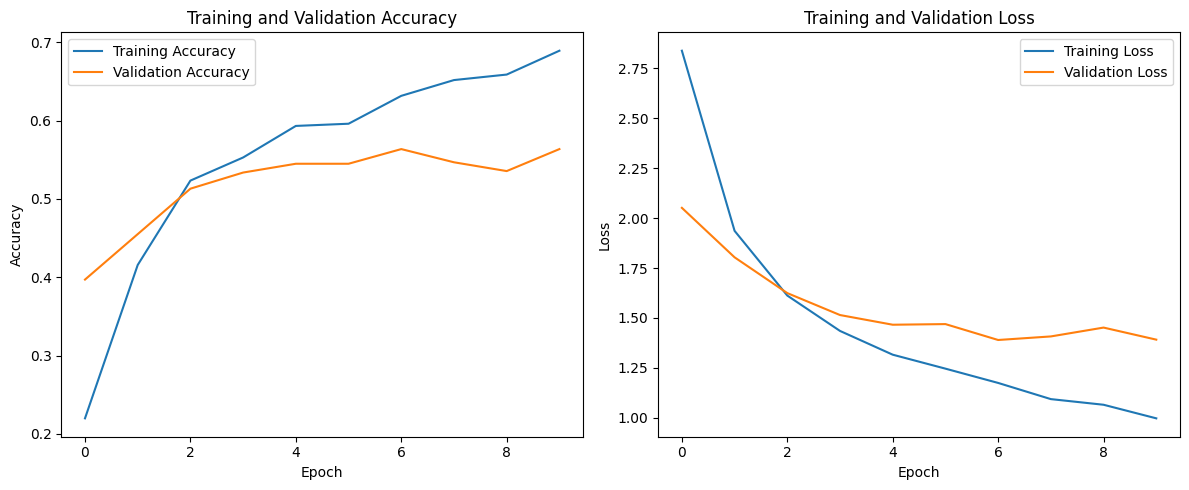

In [35]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final.history["accuracy"], label="Training Accuracy")
plt.plot(history_final.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final.history["loss"], label="Training Loss")
plt.plot(history_final.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Unseen Test-Set Evaluation

The final model is evaluated on the untouched PlantDoc test set. This provides an unbiased assessment of how well the trained model generalises to unseen images.

In [38]:
test_loss, test_accuracy = final_model.evaluate(test_ds, verbose=1)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 400ms/step - accuracy: 0.5040 - loss: 1.6411
Test Loss: 1.6411
Test Accuracy: 0.504


### 6.1 Classification Metrics

Accuracy alone may not fully reflect performance because the PlantDoc classes are imbalanced. Precision, recall and F1-score are therefore calculated for the unseen test set.

In [39]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_prob = final_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=model_classes,
    digits=3,
    zero_division=0
)

print(report)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step
                            precision    recall  f1-score   support

           Apple_Scab_Leaf      0.714     0.500     0.588        10
                Apple_leaf      0.438     0.778     0.560         9
           Apple_rust_leaf      0.778     0.700     0.737        10
          Bell_pepper_leaf      0.500     0.250     0.333         8
     Bell_pepper_leaf_spot      0.571     0.444     0.500         9
            Blueberry_leaf      0.389     0.636     0.483        11
               Cherry_leaf      0.333     0.100     0.154        10
       Corn_Gray_leaf_spot      0.333     0.500     0.400         4
          Corn_leaf_blight      0.833     0.417     0.556        12
            Corn_rust_leaf      0.529     0.900     0.667        10
                Peach_leaf      0.556     0.556     0.556         9
  Potato_leaf_early_blight      0.190     0.286     0.229        14
   Potato_leaf_late_blight      0.062     0.125     0.083         8
        

### 6.2 Confusion Matrix

The confusion matrix shows the prediction patterns across the 27 plant classes and highlights categories that are frequently confused by the model.

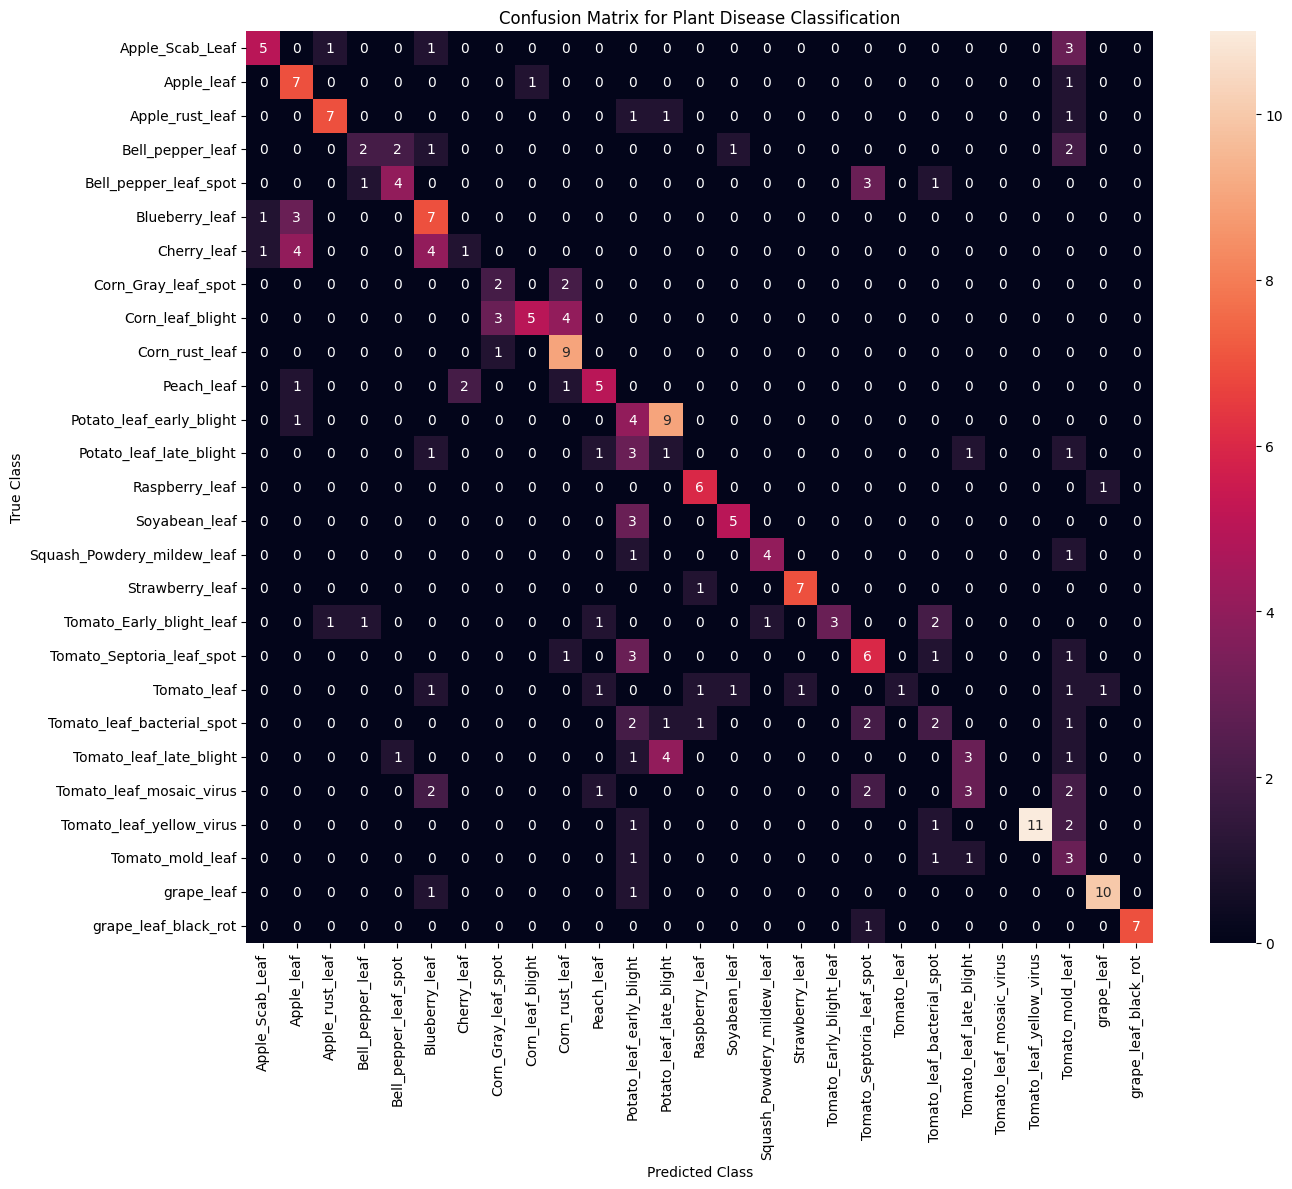

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model_classes,
    yticklabels=model_classes
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix for Plant Disease Classification")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.3 Model Explainability

Grad-CAM is used to visualise the image regions that contribute to the model's prediction. This provides an interpretable view of whether the model is focusing on relevant leaf regions when making a classification.

In [46]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    base_model = model.get_layer("mobilenetv2_1.00_224")
    last_conv_layer = base_model.get_layer("out_relu")
    augmentation_layer = model.get_layer("sequential")
    pooling_layer = model.get_layer("global_average_pooling2d_1")
    dense_layer = model.get_layer("dense_1")

    x = augmentation_layer(img_array, training=False)
    x = preprocess_input(x)

    grad_model = tf.keras.models.Model(
        base_model.input,
        [last_conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_output = grad_model(x)
        pooled_output = pooling_layer(base_output)
        predictions = dense_layer(pooled_output)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index.numpy())

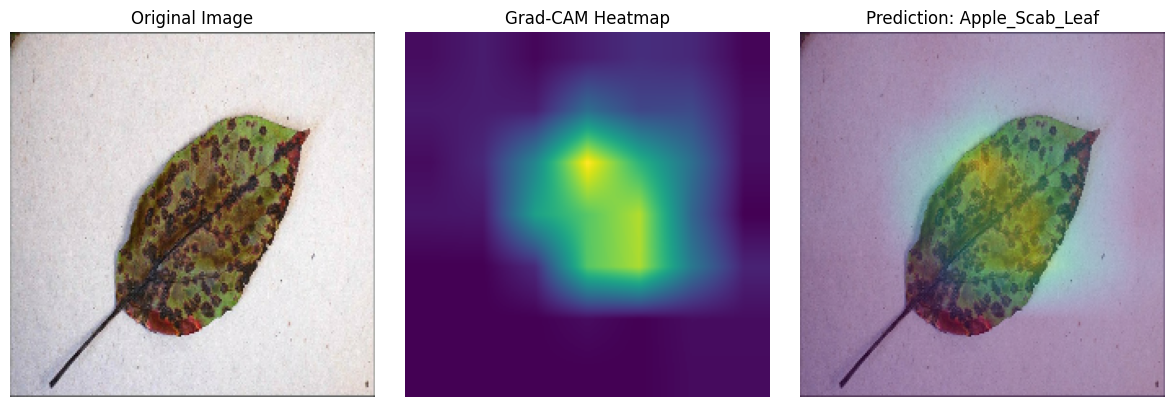

True Class: Apple_Scab_Leaf
Predicted Class: Apple_Scab_Leaf


In [47]:
for images, labels in test_ds.take(1):
    sample_image = images[0]
    true_label = labels[0]

img_array = tf.expand_dims(sample_image, axis=0)
heatmap, predicted_index = make_gradcam_heatmap(img_array, final_model)

heatmap_resized = tf.image.resize(
    heatmap[..., tf.newaxis],
    IMG_SIZE
).numpy().squeeze()

original_image = sample_image.numpy().astype("uint8")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_image)
plt.imshow(heatmap_resized, alpha=0.4)
plt.title(
    "Prediction: " + model_classes[predicted_index]
)
plt.axis("off")

plt.tight_layout()
plt.show()

print("True Class:", model_classes[true_label.numpy()])
print("Predicted Class:", model_classes[predicted_index])

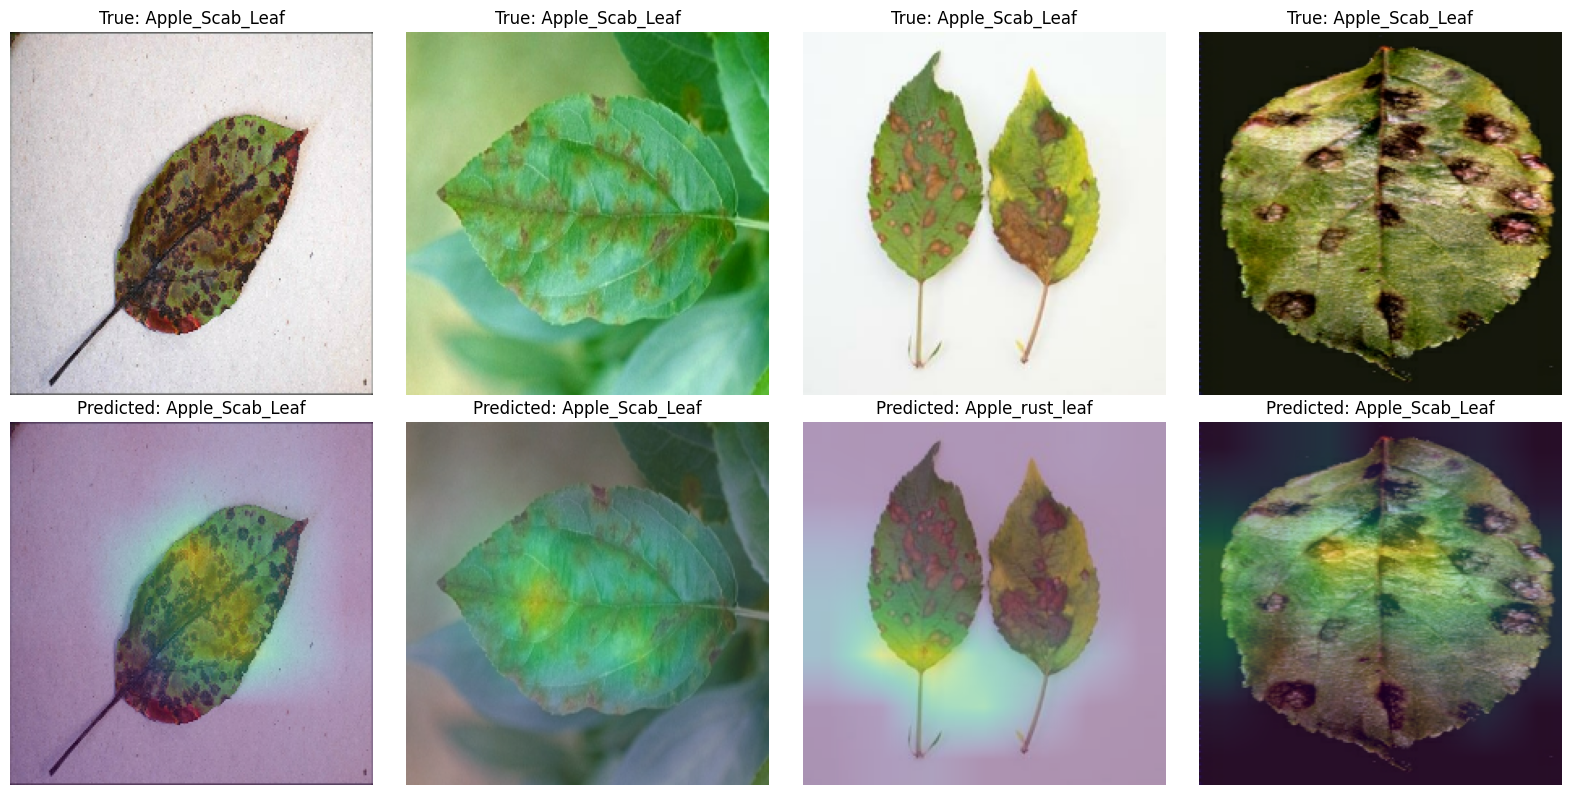

In [48]:
for images, labels in test_ds.take(1):
    sample_images = images[:4]
    sample_labels = labels[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img_array = tf.expand_dims(sample_images[i], axis=0)
    heatmap, predicted_index = make_gradcam_heatmap(img_array, final_model)

    heatmap_resized = tf.image.resize(
        heatmap[..., tf.newaxis],
        IMG_SIZE
    ).numpy().squeeze()

    axes[0, i].imshow(sample_images[i].numpy().astype("uint8"))
    axes[0, i].set_title("True: " + model_classes[sample_labels[i].numpy()])
    axes[0, i].axis("off")

    axes[1, i].imshow(sample_images[i].numpy().astype("uint8"))
    axes[1, i].imshow(heatmap_resized, alpha=0.4)
    axes[1, i].set_title("Predicted: " + model_classes[predicted_index])
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 7. Discussion and Business Implications

### Model Performance

The final MobileNetV2 model achieved 50.4% accuracy on the 252-image unseen test set. The macro F1-score was 49.9%, showing that performance varies across the 27 classes. Some classes achieved strong F1-scores, while others had substantially weaker results, particularly classes with limited or visually similar examples.

### Model Interpretation

The confusion matrix shows that misclassifications occur across several visually similar plant categories. The Grad-CAM analysis indicates that the model can focus on relevant leaf regions and disease patterns, supporting the interpretability of its predictions.

### Strengths

The use of transfer learning allowed a pretrained MobileNetV2 network to learn useful visual representations from a relatively small image dataset. Data augmentation improved variation during training, while stratified validation helped maintain class proportions.

### Limitations

The dataset is highly imbalanced, with training class sizes ranging from 2 to 223 images. One class was excluded because it contained only two training images and was absent from the test set. The test set also contains only 252 images, limiting the reliability of class-level conclusions. The validation and training curves show a performance gap, indicating some overfitting.

### Business Implications

The model demonstrates potential as a decision-support component for an agritech application, but the current performance is not sufficient for fully automated disease diagnosis. Predictions should therefore be presented as assistance to farmers or agricultural experts rather than as definitive diagnoses.

### Recommendations

Future development should collect more representative field images, especially for underrepresented classes, and improve class balance. Additional fine-tuning, higher-quality labelled data and testing on images from different farms and environments could improve generalisation. A production system should also provide prediction confidence and an option to refer uncertain cases to an agricultural expert.

### Conclusion

The project demonstrates an end-to-end deep learning pipeline for plant disease classification, covering data exploration, preprocessing, augmentation, model experimentation, transfer learning, validation, unseen test evaluation and explainability. The results show that MobileNetV2 can learn useful visual patterns from PlantDoc images, while also highlighting the importance of data quality, class balance and external validation before deployment.

## 8. References

Singh, D., Jain, N., Jain, P., Kayal, P., Kumawat, S. and Batra, N. (2020) ‘PlantDoc: A dataset for visual plant disease detection’, *Proceedings of the 7th ACM IKDD CoDS and 25th COMAD*, pp. 249–253.

TensorFlow (2024) *TensorFlow documentation*. Available at: https://www.tensorflow.org/ (Accessed: 17 September 2026).

Keras (2024) *Keras documentation*. Available at: https://keras.io/ (Accessed: 17 September 2026).

Kaggle (2024) *PlantDoc Dataset*. Available at: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset (Accessed: 17 September 2026).